# COMPSCI 714 — Coding Assignment 1 Notebook - S1 2026

**Student name:** Keanu De Cleene

**Student UPI:**  kdec819

**Student ID:**  605624678

**GenAI policy**  
This is a Lane 2 assignment, meaning you are authorised to use GenAI tools as support to complete the work. 
You may use Generative AI tools to support your coding and understanding, but not to complete the assignment for you.

*You may use GenAI to:*
- debug errors and understand code,
- clarify concepts (e.g., recall, loss functions, saliency maps),
- get guidance on how to implement components (e.g., training loops, Optuna setup).

*You should not use GenAI to:*
- generate full solutions and submit them as your own,
- copy code you do not understand,
- produce written answers not based on your own results.

*Key expectation*

You must be able to explain your code and justify your results.

**GenAI usage disclosure:** 

For transparency and self-reflection purpose, state here whether you used any Generative AI tools, and if so, briefly describe how it helped you complete the assignment:

Used genAI for clarifying concepts.

---

# Instructions

This notebook is a **submission template** for the assignment, including both instructions and cells to implement and enter your answers.

## How to use this notebook
For each task, you will usually find:
1. an **Instructions/Requirements/Required outputs** section explaining what the task is about, what outputs are expected, and any additional requirements,
2. one or more **TODO code cell** with code to run, complete and/or write from scratch,
3. a **Comment your results** section to enter short written comments to specified questions.

## General requirements
- Fill your name, UPI, ID at the top of the Notebook.
- Complete the GenAI usage disclosure at the top of the Notebook.
- Complete all required `TODO` cells. Some of them are prefilled and you need to replace `None` values and/or complete part of the code as instructed. 
- Answer all the **Comment your results** questions directly in the Notebook in the markdown cell.
- Run your notebook from top to bottom before submission.
- Keep outputs visible.
- Do **not** delete task headings.
- You may add extra cells if needed, but label them clearly.
- Use the provided random seed unless instructed otherwise.
- Keep variable names clear and consistent.

## What markers will check
Markers will check that:
- your code follows the task specifications,
- required outputs are shown,
- written answers are coherent, concise (a few sentences are enough) and refer to your **actual numerical results** when relevant,
- the notebook is globally readable and well structured.

## Notebook checklist before submitting
Before submitting, make sure:
- your name, UPI and ID are stated at the start of the Notebook.
- you disclosed GenAI usage at the top of the Notebook.
- all cells run without errors,
- all required outputs are visible,
- all written response sections are completed,
- plots have readable titles/labels where relevant,
- the final notebook is neat and easy to mark.


# Setup

Import libraries and set random seeds for reproducibility.


In [3]:
# TODO: Run this cell first

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_recall_curve

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# You may need to install Optuna if it is not available in your environment.
!pip install optuna
import optuna
from optuna.samplers import TPESampler

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Part 1 — Train and evaluate a simple MLP on tabular data (11 marks)

## Learning goal
In Part 1, your goal is to **apply, adapt and expand code patterns from Lectutorials 1 to 3** on a simple dataset.

This part focuses on:
- correctly adapting standard preprocessing tools,
- comparing random splitting and stratified splitting,
- implementing and training a simple MLP on the stratified split,
- interpreting model performance using losses and multiple evaluation metrics.
- analyse the precision-recall trade-off on the task using the precision-recall curve.
- tuning hyperparameters and comparing their importance. 


## Task 1.1 — Load and inspect the dataset (1 mark)

### Instructions
Use the OpenML dataset `German-Credit-Risk-with-Target`, loaded with the fetch_openml function.

You must:
1. load the dataset into `X` (features) and `y` (targets),
2. inspect its structure,
3. identify potential missing values,
4. identify numeric and categorical features.

### Required outputs (0.5 marks)
Show:
- the shape of `X`,
- the class distribution of the target,
- the number of numeric features and the number of categorical features,
- the name, non-null count and data type of each feature,
- a preview of the 5 first rows of `X`.

In [4]:
# TODO: Complete this dataset loading and inspection guide


# Step 1: load the dataset from OpenML
data = fetch_openml(name="credit-g", version=1, as_frame=True)

# Step 2: extract features and target (hint: the features and targets are stored in specific attributes of the loaded dataset)
X = data.data
y = data.target

# Step 3: identify numeric and categorical columns

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# Step 4: print the required outputs

print("shape of X:", X.shape, "\n")

print("distribution of y:", y.value_counts(), "\n")

print("numeric features:", len(numeric_features), "\n")

print("categorical features:", len(categorical_features), "\n")

features = pd.DataFrame({
    "feature_name": X.columns,
    "non_null_count": X.notnull().sum().values,
    "data_type": X.dtypes.astype(str).values
})


print(features)

print("first 5 rows of X:")
X.head()





shape of X: (1000, 20) 

distribution of y: class
good    700
bad     300
Name: count, dtype: int64 

numeric features: 7 

categorical features: 13 

              feature_name  non_null_count data_type
0          checking_status            1000  category
1                 duration            1000   float64
2           credit_history            1000  category
3                  purpose            1000  category
4            credit_amount            1000   float64
5           savings_status            1000  category
6               employment            1000  category
7   installment_commitment            1000   float64
8          personal_status            1000  category
9            other_parties            1000  category
10         residence_since            1000   float64
11      property_magnitude            1000  category
12                     age            1000   float64
13     other_payment_plans            1000  category
14                 housing            1000  category
1

c:\Users\keanu\anaconda3\envs\compsci714\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,4.0,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,2.0,real estate,22.0,none,own,1.0,skilled,1.0,none,yes
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,3.0,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,4.0,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,4.0,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes


## Task 1.2 — Compare random and stratified splitting (1 mark)

### Instructions
Create **two versions** of the train/validation/test sets:
1. a **random split without stratification**,
2. a **stratified split**.

For both versions, split the dataset into 70% training, 15% validation, and 15% test sets.

### Requirements
- Use `random_state=seed` in all splits.
- For the stratified version, stratify on the target variable.

### Required outputs (0.5 marks)
Show, for **both** random and stratified splitting:
- the number of samples in each set.
- the class proportions in each set.

In [5]:
# TODO: Complete this splitting guide

X_train_rand, X_temp_rand, y_train_rand, y_temp_rand = train_test_split(X, y, test_size=0.3, random_state=seed)
X_valid_rand, X_test_rand, y_valid_rand, y_test_rand = train_test_split(X_temp_rand, y_temp_rand, test_size=0.5, random_state=seed)

X_train_strat, X_temp_strat, y_train_strat, y_temp_strat = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
X_valid_strat, X_test_strat, y_valid_strat, y_test_strat = train_test_split(X_temp_strat, y_temp_strat, test_size=0.5, random_state=seed, stratify=y_temp_strat)

def class_proportions(y_split):
        return y_split.value_counts(normalize=True)

# TODO: print sets sizes and class proportions for both strategies

print("random split:")
print("samples in each set:")
print("Train size", len(X_train_rand))
print("validation size", len(X_valid_rand))
print("test size", len(X_test_rand))

print("\ntrain class proportions:")
print(class_proportions(y_train_rand))

print("\nvalidation class proportions:")
print(class_proportions(y_valid_rand))

print("\ntest class proportions:")
print(class_proportions(y_test_rand))



print("\nStratified split:")
print("samples in each set:")
print("Train size", len(X_train_strat))
print("validation size", len(X_valid_strat))    
print("test size", len(X_test_strat))


print("\ntrain class proportions:")
print(class_proportions(y_train_strat))
print("\nvalidation class proportions:")
print(class_proportions(y_valid_strat))
print("\ntest class proportions:")
print(class_proportions(y_test_strat))



random split:
samples in each set:
Train size 700
validation size 150
test size 150

train class proportions:
class
good    0.701429
bad     0.298571
Name: proportion, dtype: float64

validation class proportions:
class
good    0.66
bad     0.34
Name: proportion, dtype: float64

test class proportions:
class
good    0.733333
bad     0.266667
Name: proportion, dtype: float64

Stratified split:
samples in each set:
Train size 700
validation size 150
test size 150

train class proportions:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64

validation class proportions:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64

test class proportions:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


### Comment your results (0.5 marks)
Use your numerical results to compare the two splitting approaches.

Discuss:
- how similar or different the class proportions are across train, validation, and test,
- which approach appears more reliable for this dataset, and why.

**Your answer:**
  
-  both approaches split the sample sizes correctly but the proportions were a bit different. the training set was close to original distribution, but the validation set had more bad cases, and the test set and more good cases. The stratified split kept the class proportions the same across all sets at 70% good and 30% bad. 

- The stratified approach seems more reliable for keeping the original class distribution in every split. This makes all of the sets more representative of the full dataset, which causes a more stable evaluation of the model


## Task 1.3 — Build the preprocessing pipeline (1 marks)

### Instructions
Build a preprocessing pipeline using `ColumnTransformer` and apply it to the **stratified sets**.

### Required preprocessing
- For numeric columns: median imputation and standard scaling.
- For categorical columns: most-frequent imputation and one-hot encoding with `handle_unknown="ignore"`.

### Important rule
Fit the preprocessing pipeline on the **training set only**, then transform validation and test sets.

### Required outputs (0.5 marks)
Show:
- the numeric pipeline,
- the categorical pipeline,
- the preprocessing `ColumnTransformer` object showing which pipeline is applied to which features,
- processed shapes for train / validation / test sets.


In [6]:
# TODO: Complete this preprocessing guide

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_strat = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_strat_proc = preprocess_strat.fit_transform(X_train_strat)
X_valid_strat_proc = preprocess_strat.transform(X_valid_strat)
X_test_strat_proc = preprocess_strat.transform(X_test_strat)

X_train_rand_proc = preprocess_strat.fit_transform(X_train_rand)
X_valid_rand_proc = preprocess_strat.transform(X_valid_rand)
X_test_rand_proc = preprocess_strat.transform(X_test_rand)



# TODO: Show pipelines, preprocessing strat and print processed sets shapes

print("\nnumeric pipeline:", numeric_pipeline)
print("\ncategorical pipeline:", categorical_pipeline)
print("\npreprocessing strategy:", preprocess_strat)


print("\nX_train_strat_proc shape:", X_train_strat_proc.shape)
print("\nX_valid_strat_proc shape:", X_valid_strat_proc.shape)
print("\nX_test_strat_proc shape:", X_test_strat_proc.shape)
print("\nX_train_rand_proc shape:", X_train_rand_proc.shape)
print("\nX_valid_rand_proc shape:", X_valid_rand_proc.shape)
print("\nX_test_rand_proc shape:", X_test_rand_proc.shape)





numeric pipeline: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

categorical pipeline: Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessing strategy: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['duration', 'credit_amount',
                                  'installment_commitment', 'residence_since',
                                  'age', 'existing_credits',
                                  'num_dependents']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImp

### Enter your answers (0.5 marks)
Briefly justify:
- the number of features after applying the preprocessing pipelines,
- why the preprocessing must be fitted only on the training data.

**Your answer:**  

-  the number of features changed because the categorical variables were transformed using one-hot encoding creating more columns, whereas the simpleimputer just fills missing values. 
- the preprocessing must be fitted only on the training data so we avoid data leakage. If the imputer, scaler, or encoder were fitted on the the test or validation sets the information from those sets would influence the preprocessing. This would make the evaluation unfair as we want to test the model on this data and not learn from it. 


## Task 1.4 — Convert data to tensors and dataloaders (1 mark)

### Instructions
Convert the processed arrays to PyTorch tensors and create dataloaders.

### Requirements
- Inputs must use `torch.float32`.
- Labels must be converted to binary `0/1`.
- Use batch size `64`.

### Required outputs (0.5 marks)
Show:
- the observed target labels,
- the label mapping used,
- tensor shapes for all sets,
- the number of batches in the training, validation and test loaders. 


In [7]:
# TODO: Complete this tensor / dataloader guide

label_values = np.unique(y_train_strat)
label_map = {'bad': 1, 'good': 0}

def encode(y, mapping):
    return np.array([mapping[val] for val in y], dtype=np.float32)


y_train_rand_num, y_valid_rand_num, y_test_rand_num = encode(y_train_rand, label_map), encode(y_valid_rand, label_map), encode(y_test_rand, label_map)
y_train_strat_num, y_valid_strat_num, y_test_strat_num = encode(y_train_strat, label_map), encode(y_valid_strat, label_map), encode(y_test_strat, label_map)

X_train_rand_tensor, X_valid_rand_tensor, X_test_rand_tensor = torch.FloatTensor(X_train_rand_proc), torch.FloatTensor(X_valid_rand_proc), torch.FloatTensor(X_test_rand_proc)
X_train_strat_tensor, X_valid_strat_tensor, X_test_strat_tensor = torch.FloatTensor(X_train_strat_proc), torch.FloatTensor(X_valid_strat_proc), torch.FloatTensor(X_test_strat_proc)

y_train_rand_tensor, y_valid_rand_tensor, y_test_rand_tensor = torch.FloatTensor(y_train_rand_num), torch.FloatTensor(y_valid_rand_num), torch.FloatTensor(y_test_rand_num)
y_train_strat_tensor, y_valid_strat_tensor, y_test_strat_tensor = torch.FloatTensor(y_train_strat_num), torch.FloatTensor(y_valid_strat_num), torch.FloatTensor(y_test_strat_num)

train_loader_rand = DataLoader(TensorDataset(X_train_rand_tensor, y_train_rand_tensor), batch_size=64, shuffle=True)
valid_loader_rand = DataLoader(TensorDataset(X_valid_rand_tensor, y_valid_rand_tensor), batch_size=64, shuffle=False)
test_loader_rand = DataLoader(TensorDataset(X_test_rand_tensor, y_test_rand_tensor), batch_size=64, shuffle=False)
train_loader_strat = DataLoader(TensorDataset(X_train_strat_tensor, y_train_strat_tensor), batch_size=64, shuffle=True)
valid_loader_strat = DataLoader(TensorDataset(X_valid_strat_tensor, y_valid_strat_tensor), batch_size=64, shuffle=False)
test_loader_strat = DataLoader(TensorDataset(X_test_strat_tensor, y_test_strat_tensor), batch_size=64, shuffle=False)



# TODO: Display observed target labels, label mapping, print tensor shapes in sets and number of batches in loaders for both strategies

print("\nobserved target labels:", label_values)
print("\nlabel mapping:", label_map)

print("\ntensor shapes random split):")
print(X_train_rand_tensor.shape)
print(X_valid_rand_tensor.shape)
print(X_test_rand_tensor.shape)
print(y_train_rand_tensor.shape)
print(y_valid_rand_tensor.shape)
print(y_test_rand_tensor.shape)

print("\ntensor shapes stratified split):")
print("X_train_strat_tensor:", X_train_strat_tensor.shape)
print("X_valid_strat_tensor:", X_valid_strat_tensor.shape)
print("X_test_strat_tensor:", X_test_strat_tensor.shape)
print("y_train_strat_tensor:", y_train_strat_tensor.shape)
print("y_valid_strat_tensor:", y_valid_strat_tensor.shape)
print("y_test_strat_tensor:", y_test_strat_tensor.shape)

print("\nnumber of batches:")
print("train_loader_rand:", len(train_loader_rand))
print("valid_loader_rand:", len(valid_loader_rand))
print("test_loader_rand:", len(test_loader_rand))
print("train_loader_strat:", len(train_loader_strat))
print("valid_loader_strat:", len(valid_loader_strat))
print("test_loader_strat:", len(test_loader_strat))



observed target labels: ['bad' 'good']

label mapping: {'bad': 1, 'good': 0}

tensor shapes random split):
torch.Size([700, 61])
torch.Size([150, 61])
torch.Size([150, 61])
torch.Size([700])
torch.Size([150])
torch.Size([150])

tensor shapes stratified split):
X_train_strat_tensor: torch.Size([700, 61])
X_valid_strat_tensor: torch.Size([150, 61])
X_test_strat_tensor: torch.Size([150, 61])
y_train_strat_tensor: torch.Size([700])
y_valid_strat_tensor: torch.Size([150])
y_test_strat_tensor: torch.Size([150])

number of batches:
train_loader_rand: 11
valid_loader_rand: 3
test_loader_rand: 3
train_loader_strat: 11
valid_loader_strat: 3
test_loader_strat: 3


### Comment your results (0.5 mark)
How many batches are there in the each set and how many samples are there in each training batch?

**Your answer:**  

-  11 batches in the training loaders with 10 batches of 64 samples + one partial batch with 60 samples. 
- 3 batches in the validation and testing loaders with 2 batches of 64 samples + one partial batch of 22 samples


## Task 1.5 — Define a simple MLP (1 mark)

### Instructions
Define the model exactly as specified below.

### Required architecture
- `Linear(n_features, 64)`
- `ReLU`
- `Linear(64, 32)`
- `ReLU`
- `Linear(32, n_outputs)`

### Requirements
- Define the appropriate number of output neurons for the classification problem at hand.
- The architecture must match this specification exactly.

### Required outputs (0.5 marks)
Show: 
- the model architecture for an instance of the class SimpleMLP.
- the output of a forward pass on one training set instance.


In [8]:
# TODO: Complete this model definition guide

class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

model_strat = SimpleMLP(10)
print(model_strat)
print(f"Model output(s) for a sample input: {model_strat(torch.randn(10))}")


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Model output(s) for a sample input: tensor([-0.0434], grad_fn=<ViewBackward0>)


### Comment your results (0.5 marks)
Briefly explain how many output neurons you used and why.

**Your answer:**  

-  I used 1 output neuron because this is binary classification. The model only needs to make one logit value every instance, this matches BCEwithLogitsLoss where a value close to 1 can indicate the positive class with a value close to 0 the other.


## Task 1.6 — Train and evaluate the model on the stratified sets (2.5 marks)

### Instructions
Train and evaluate the model using the **stratified sets**.

Helper functions are already provided for:
- training one epoch,
- evaluating the loss,
- performing a binary prediction using a threshold on the output neuron value (a.k.a., logit value),
- computing multiple evaluaton metrics.

Make sure to understand what these functions do so that you can use them to complete the model training and evaluation code for this task, and later in the assignment if needed.

### Training specification
Use `BCEWithLogitsLoss`, `Adam(lr=1e-3)`, `20` epochs, and batch size `64`.

### Additional tracking requirement
During training, also compute and store:
- training accuracy per epoch,
- validation accuracy per epoch.

Display the train/validation accuracies on the **same learning-curve figure** as the train/validation losses.

### Evaluation requirement
Evaluate the model on the **stratified test set** using:
- Accuracy,
- Precision (**bad-risk class**),
- Recall (**bad-risk class**),
- F1 score,
- confusion matrix.


### Required outputs (1 mark)
Show:
- training loss per epoch,
- validation loss per epoch,
- training accuracy per epoch,
- validation accuracy per epoch,
- a learning-curve plot with training and validation losses **and** accuracies,
- final test Accuracy,
- final test Precision (**bad-risk class**),
- final test Recall (**bad-risk class**),
- final test F1,
- the test confusion matrix.


In [9]:
# TODO: Run, read and understand the training and evaluation helper fonction below (feel free to use GenAI to explain any lines you don't understand) 
# DO NOT MODIFY THE CODE IN THIS CELL

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch).squeeze(1)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def evaluate_loss(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch).squeeze(1)
        loss = loss_fn(logits, y_batch)
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def predict_binary(model, loader, threshold=0.5): 
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())
    return np.array(all_probs), np.array(all_preds), np.array(all_targets)

def evaluate_binary_metrics(model, loader, positive_class_label=1):
    probs, preds, targets = predict_binary(model, loader, threshold=0.5)
    acc = accuracy_score(targets, preds)
    precision = precision_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)
    cm = confusion_matrix(targets, preds)
    recall = recall_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    return {
        "accuracy": acc,
        "precision": precision,
        "f1": f1,
        "confusion_matrix": cm,
        "recall": recall,
        "probs": probs,
        "preds": preds,
        "targets": targets,
    }


In [10]:
# TODO: Complete the code below (i.e., replace None values and implement the training loop using the relevant helper functions)
model = SimpleMLP(X_train_strat_tensor.shape[1]).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 20

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
# TODO: Training loop here

for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader_strat, optimizer, loss_fn)

    valid_loss = evaluate_loss(model, valid_loader_strat, loss_fn)

    train_metrics = evaluate_binary_metrics(model, train_loader_strat, positive_class_label=1)
    valid_metrics = evaluate_binary_metrics(model, valid_loader_strat, positive_class_label=1)

    train_acc = train_metrics["accuracy"]
    valid_acc = valid_metrics["accuracy"]
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Valid Acc: {valid_acc:.4f}"
    )

results = evaluate_binary_metrics(model, test_loader_strat, positive_class_label=1)

Epoch 01/20 | Train Loss: 0.6576 | Valid Loss: 0.6448 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch 02/20 | Train Loss: 0.6028 | Valid Loss: 0.6202 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch 03/20 | Train Loss: 0.5720 | Valid Loss: 0.6174 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch 04/20 | Train Loss: 0.5567 | Valid Loss: 0.6071 | Train Acc: 0.7000 | Valid Acc: 0.7000
Epoch 05/20 | Train Loss: 0.5367 | Valid Loss: 0.5897 | Train Acc: 0.7186 | Valid Acc: 0.7000
Epoch 06/20 | Train Loss: 0.5166 | Valid Loss: 0.5762 | Train Acc: 0.7343 | Valid Acc: 0.7067
Epoch 07/20 | Train Loss: 0.4986 | Valid Loss: 0.5619 | Train Acc: 0.7700 | Valid Acc: 0.7200
Epoch 08/20 | Train Loss: 0.4781 | Valid Loss: 0.5482 | Train Acc: 0.7786 | Valid Acc: 0.7400
Epoch 09/20 | Train Loss: 0.4618 | Valid Loss: 0.5325 | Train Acc: 0.7886 | Valid Acc: 0.7733
Epoch 10/20 | Train Loss: 0.4494 | Valid Loss: 0.5240 | Train Acc: 0.8000 | Valid Acc: 0.7600
Epoch 11/20 | Train Loss: 0.4397 | Valid Loss: 0.5182 | Trai


Stratified test results
Accuracy: 0.74
Precision on bad risk: 0.5714285714285714
Recall on bad risk: 0.5333333333333333
F1: 0.5517241379310344


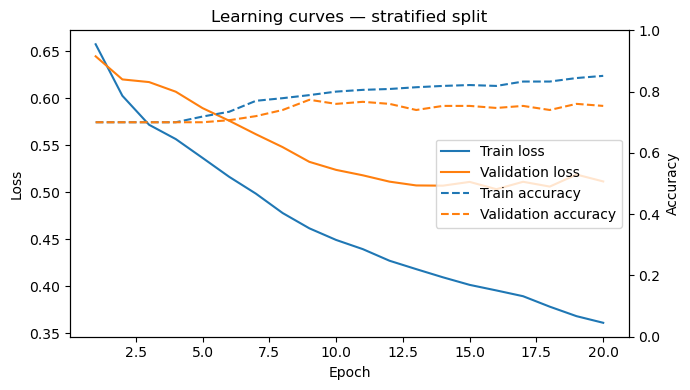

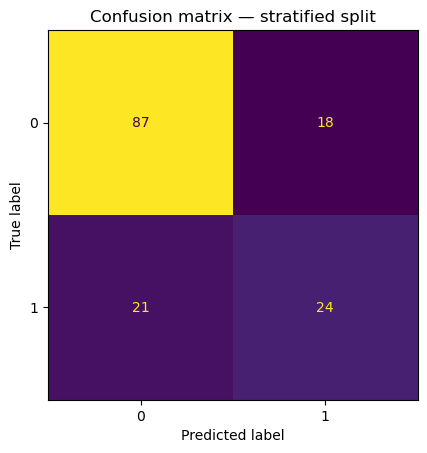

In [11]:
# TODO: Run this cell to display the results and learning curves once your model is trained and evaluated on the stratified sets
print("\nStratified test results")
print("Accuracy:", results["accuracy"])
print("Precision on bad risk:", results["precision"])
print("Recall on bad risk:", results["recall"])
print("F1:", results["f1"])

results_part1_df = pd.DataFrame([
    {
        "accuracy": results["accuracy"],
        "precision": results["precision"],
        "f1": results["f1"],
        "recall": results["recall"],
    }
])

epochs = range(1, len(train_losses) + 1)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, train_losses, label="Train loss")
ax1.plot(epochs, valid_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(epochs, train_accs, linestyle="--", label="Train accuracy")
ax2.plot(epochs, valid_accs, linestyle="--", label="Validation accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")
plt.title("Learning curves — stratified split")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay(results["confusion_matrix"]).plot(colorbar=False)
plt.title("Confusion matrix — stratified split")
plt.show()

### Comment the results (1.5 marks)
Use your results to discuss model evaluation.

Explicitly refer to:
- the overall behaviour of the training and validation losses,
- the final Accuracy,
- the final Precision (**bad-risk class**),
- the final Recall (**bad-risk class**),
- the final F1 score,
- at least one observation from the confusion matrix.

Explain what these results suggest about model performance, not just repeat the numbers.

**Your answer:** 

- the training loss decreased over all the epochs whilst the valid loss was decreasing gradually until it slowed down and started to slowly increase towards the end of the epochs. This means that the model was learning well but started to overfit. 

- the final accuracy was 0.7467 showing that the model correctly classified close to 75% of the test instances. For the true bad risk class precision it was 0.8073 meaning it was correct most of the time when predicting a case as bad risk. The recall was 0.8381 meaning the model identified a decently high proportion of the bad risk cases overall. The F1 score was 0.8224 meaning there was a relatively strong balance betweem recall and precision for prediciting bad risk cases.

- The confusion matrix shows that the model correctly identified 88 bad risk cases but missed 17 bad risk cases. But it incorrectly labelled 21 good cases as bad which could be quite detrimental in a real world application of this model. The model performs fiarly okay for identifying bad-risk applicants, but we would need to address the slight overfitting of our model with things like dropout or early stopping.


## Task 1.7 — Compare different binary decision thresholds (1.5 marks)

### Instructions
Using the trained model, compare the effect of using different **decision thresholds** when converting predicted probabilities into binary class predictions.

Use **five** different thresholds.

### Important note
The threshold changes the **final prediction rule**, not the model weights.  
So you should **reuse the trained model** from Task 1.6 and evaluate it with different thresholds rather than retraining the network from scratch.

### Required comparison
For each threshold, evaluate the model on the **stratified validation set** and the **stratified test set**.

Report at least:
- Accuracy,
- Precision (**bad-risk class**),
- F1 score,
- Recall (**bad-risk class**).

Present the results in a clear table, and include a short comparison discussing the trade-off between a **lower** and a **higher** threshold.

### Required outputs (1 mark)
Show:
- the list of tested thresholds,
- a table of validation metrics,
- a table of test metrics,
- a **precision-recall curve** for the validation set, with the tested thresholds highlighted on the curve,
- a short interpretation of how threshold choice changes Precision (**bad-risk class**) and Recall (**bad-risk class**).

> Notes: 
> - The **precision-recall curve** was not covered in the Lectutorials, so you need to do some personal research to solve this task. 
> - You can use the `precision_recall_curve` function, already loaded from Scikit Learn to generate the curve.


Tested thresholds: [0.1, 0.3, 0.5, 0.7, 0.9]

Validation metrics by threshold


,threshold,accuracy,precision,recall,f1,confusion_matrix
0,0.1,0.566667,0.401961,0.911111,0.557823,"[[44, 61], [4, 41]]"
1,0.3,0.686667,0.483333,0.644444,0.552381,"[[74, 31], [16, 29]]"
2,0.5,0.753333,0.605263,0.511111,0.554217,"[[90, 15], [22, 23]]"
3,0.7,0.766667,0.777778,0.311111,0.444444,"[[101, 4], [31, 14]]"
4,0.9,0.700000,0.000000,0.000000,0.000000,"[[105, 0], [45, 0]]"



Test metrics by threshold


,threshold,accuracy,precision,recall,f1,confusion_matrix
0,0.1,0.640000,0.450549,0.911111,0.602941,"[[55, 50], [4, 41]]"
1,0.3,0.720000,0.526316,0.666667,0.588235,"[[78, 27], [15, 30]]"
2,0.5,0.740000,0.571429,0.533333,0.551724,"[[87, 18], [21, 24]]"
3,0.7,0.726667,0.571429,0.355556,0.438356,"[[93, 12], [29, 16]]"
4,0.9,0.700000,0.000000,0.000000,0.000000,"[[105, 0], [45, 0]]"


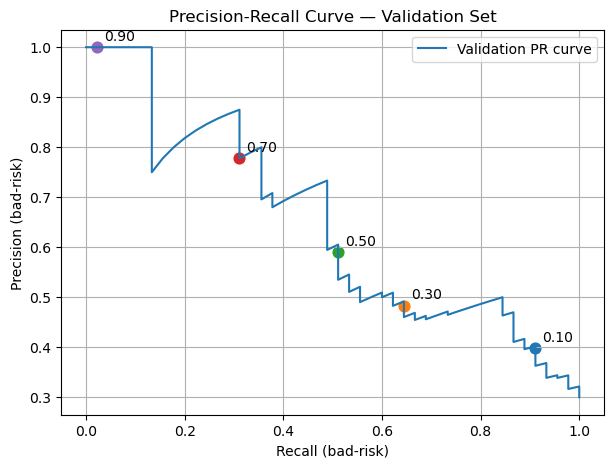

In [ ]:

# TODO: Evaluate the trained Part 1 model with several decision thresholds and compare the results
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

def evaluate_binary_metrics_at_threshold(model, loader, threshold, positive_class_label=1):
    _, preds, targets = predict_binary(model, loader, threshold=threshold)
    acc = accuracy_score(targets, preds)
    precision = precision_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)
    cm = confusion_matrix(targets, preds)
    recall = recall_score(targets, preds, pos_label=positive_class_label, zero_division=0)
    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

valid_threshold_results = pd.DataFrame([evaluate_binary_metrics_at_threshold(model, valid_loader_strat, threshold, 1) for threshold in thresholds])
test_threshold_results = pd.DataFrame([evaluate_binary_metrics_at_threshold(model, test_loader_strat, threshold,1) for threshold in thresholds])

valid_threshold_results = valid_threshold_results[
    ["threshold", "accuracy", "precision", "recall", "f1", "confusion_matrix"]
]

test_threshold_results = test_threshold_results[
    ["threshold", "accuracy", "precision", "recall", "f1", "confusion_matrix"]
]

print("thresholds used:", thresholds)

print("\nvalidation metrics by threshold")
display(valid_threshold_results)

print("\ntest metrics by threshold")
display(test_threshold_results)



valid_probs, _, valid_targets = predict_binary(model, valid_loader_strat, threshold=0.5)

precisions, recalls, pr_thresholds = precision_recall_curve(valid_targets, valid_probs, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Validation PR curve")

for t in thresholds:
    idx = np.argmin(np.abs(pr_thresholds - t))
    plt.scatter(recalls[idx], precisions[idx], s=60)
    plt.annotate(f"{t:.2f}", (recalls[idx], precisions[idx]), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Recall (bad-risk)")
plt.ylabel("Precision (bad-risk)")
plt.title("Precision-Recall Curve - Validation Set")
plt.legend()
plt.grid(True)
plt.show()




### Comment your results (0.5 mark)
Use your results to discuss how changing the decision threshold affects the model behaviour.

Explicitly refer to:
- how Accuracy changes across thresholds,
- how Precision (**bad-risk class**) changes across thresholds,
- how F1 changes across thresholds,
- how Recall (**bad-risk class**) changes across thresholds,
- which threshold you would prefer for this credit-risk task, and why.

**Your answer:**

-  



## Task 1.8 — Evaluate hyperparameter importance (2 marks)

### Instructions
Use **Optuna** to evaluate **100 configurations** of the `ConfigurableMLP` on the **stratified sets**, and evaluate which hyperparameters have the most influence of the final model performance.

### Optimisation objective
Use the **validation Recall (bad-risk class)** as the objective to maximise.

### What you need to do
1. Complete the Optuna `objective(trial)` function.
2. Use a `TPESampler`.
3. Run **100 trials**.
4. Search over a space that includes:
   - hidden-layer sizes: [64, 32], [128, 64], [256, 128], [128, 32], [256, 64], [256, 32]
   - learning rate: 1e-4 to 1e-2 (log scale)
   - batch normalisation: With or Without,
   - optimiser: Adam or AdamW.
5. Identify the best configuration based on **validation Recall (bad-risk class)**.
6. Retrain the best configuration and evaluate it on the **test set**.
7. Compare the best new model performance with the model trained in Task 1.6.
8. Evaluate the importance of each hyperparamete (i.e., how much each hyperparameter influences the final model performance).

### Required outputs (1 mark)
Show:
- the Optuna search space,
- the best trial number,
- the best hyperparameters,
- the best validation Recall (**bad-risk class**),
- a comparison of the best model after tuning with the Task 1.6 baseline on: 
   - the test Accuracy, Precision, Recall and F1 score (**bad-risk class**) 
   - the precision-recall curve
- a list of hyperparameter importance scores in descending order.

>  Notes
> - Computing hyperparameter importance was not covered in the Lectutorials, so you need to do some personal research to solve this task. 
> - You can use the `optuna.importance.get_param_importances()` function to evaluate the importance of the hyperparameters after completing the optuna study. 

In [13]:
# TODO: Run this cell to declare the configurable MLP class that will be used in the hyperparameter tuning task, and read through the code to understand how the different hyperparameters are implemented in the architecture 

class ConfigurableMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size_h1= 64,
        hidden_size_h2= 32,
        use_batchnorm=False,
    ):
        super().__init__()

        layers = []
        # ---- Inputs ----
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(input_dim))
        # ---- Layer 1 ----
        layers.append(nn.Linear(input_dim, hidden_size_h1))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size_h1))
        layers.append(nn.ReLU())
        # ---- Layer 2 ----
        layers.append(nn.Linear(hidden_size_h1, hidden_size_h2))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_size_h2))
        layers.append(nn.ReLU())
        # ---- Output layer ----
        layers.append(nn.Linear(hidden_size_h2, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [14]:
# TODO: Complete the following code (replace None values and add code where needed)

def objective(trial):
    # TODO: Complete the objective function and return the validation recall
    return None


search_space_summary = {
    "hidden_sizes": None,
    "lr": None,
    "use_batchnorm": None,
    "optimisers": None
}
print("Optuna search space:")
print(search_space_summary)


sampler = None
study = optuna.create_study(direction=None, sampler=sampler)
study.optimize(objective, n_trials=100)

best_trial = None
best_config = None

print("\nBest trial number:", best_trial.number)
print("Best validation loss:", best_trial.value)
print("Best hyperparameters:")
print(best_config)

# TODO: Complete the code to retrain the model with the best hyperparameters on the stratified training set and evaluate it on the stratified test set, then compare the results with the baseline model from Task 1.6 and perform threshold analysis as in Task 1.7
best_model = None
best_optimizer = None
loss_fn = nn.BCEWithLogitsLoss()

for _ in range(20):
    train_one_epoch(best_model, train_loader_strat, best_optimizer, loss_fn)

best_test_metrics = evaluate_binary_metrics(best_model, test_loader_strat, positive_class_label=1)

# Results comparison and threshold analysis
print("\nBest test results")
print("Accuracy:", best_test_metrics["accuracy"])
print("Bad-risk precision:", best_test_metrics["precision"])
print("Bad-risk recall:", best_test_metrics["recall"])
print("F1:", best_test_metrics["f1"])

print("\nComparison with Task 1.6 baseline:")
print("Baseline Accuracy:", results["accuracy"])
print("Baseline bad-risk precision:", results["precision"])
print("Baseline bad-risk recall:", results["recall"])
print("Baseline F1:", results["f1"])

# TODO: Threshold analysis for the best model, using same thresholds as in Task 1.7 and comparing the results with the baseline model at those thresholds


# TODO: Hyperparameter importance study: compute and display the importance of each hyperparameter in the search space based on the optimisation results

    


[I 2026-04-06 21:32:38,233] A new study created in memory with name: no-name-c1d2389a-53d1-41da-be05-4eca04f17ac4
[W 2026-04-06 21:32:38,234] Trial 0 failed with parameters: {} because of the following error: The value None could not be cast to float..
[W 2026-04-06 21:32:38,235] Trial 0 failed with value None.
[W 2026-04-06 21:32:38,235] Trial 1 failed with parameters: {} because of the following error: The value None could not be cast to float..
[W 2026-04-06 21:32:38,236] Trial 1 failed with value None.
[W 2026-04-06 21:32:38,236] Trial 2 failed with parameters: {} because of the following error: The value None could not be cast to float..
[W 2026-04-06 21:32:38,237] Trial 2 failed with value None.
[W 2026-04-06 21:32:38,237] Trial 3 failed with parameters: {} because of the following error: The value None could not be cast to float..
[W 2026-04-06 21:32:38,238] Trial 3 failed with value None.
[W 2026-04-06 21:32:38,239] Trial 4 failed with parameters: {} because of the following er

Optuna search space:
{'hidden_sizes': None, 'lr': None, 'use_batchnorm': None, 'optimisers': None}


AttributeError: 'NoneType' object has no attribute 'number'

### Comment the results (1 mark)
Use your results to address the following:
- Identify which configuration performed best.
- Compare it to the Task 1.6 baseline using the chosen metrics and threshold analysis.
- Highlight which hyperparameters appear most influential.
- Discuss the main limitations of the current model and suggest potential improvements (no need to provide additional results).

**Your answer:**  

-  


# Part 2 — CNN and Saliency maps (4 marks)

## Learning goal
In Part 2, you will apply and adapt code from the Lectutorial 5 and go beyond the scope of the Lectutorial with the implementation of saliency maps for model interpretation..

You will reuse core PyTorch skills, but apply them to robustness under distribution shift and prediction interpretability.


## Task 2.1 — Load FashionMNIST and train a baseline CNN (2 marks)

### Instructions
1. Load FashionMNIST the relevant `torchvision.datasets` function.
2. Create a training/validation sets from the training portion.
3. Define and train a baseline CNN.

### Minimum CNN requirement
You are free to define your CNN architecture yourself, but it should fit the following minimum requirements:
- Feature extraction: at least **two convolution blocks**, each of the form `Conv2d → ReLU → MaxPool2d`.
- Classifier: two fully connected layers.

> Note: You do not need to train a very large network for this task. Feel free to experiment with larger networks for your own interest if you have the time and resources. 

### Training requirements
- Use `CrossEntropyLoss`.
- Use Adam optimiser.
- Train for at least **10 epochs**.

### Required outputs (1 mark)
Show:
- the dataset sizes, 
- the CNN architecture, 
- the training and validation losses across epochs, 
- the training and validation accuracies across epochs,
- the test accuracy.


In [ ]:
# TODO: Complete this baseline CNN guide

base_transform = None # Define transformation pipeline for the images
train_dataset_full = None
test_dataset_img = None

train_dataset_img, valid_dataset_img = None, None
train_loader_img = None
valid_loader_img = None
test_loader_img = None

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = None
        self.classifier = None

    def forward(self, x):
        pass

cnn_model = None

# Training loop and evaluation for the CNN model here (similar to the MLP training loop, but using the image dataloaders and the cnn_model). 
# You might want to define some helper functions, similar to the ones defined for the MLP, to keep the code clean and modular.

test_acc = None


### Enter your answers (1 mark)
Briefly comment on whether the baseline CNN seems to learn effectively, using the plotted losses/accuracy and clean test accuracy.

**Your answer:**  

-  


## Task 2.2 — Saliency map interpretability (2 marks)


### What is a saliency map?

A saliency map is a visual explanation technique used to understand which parts of an input image most influence a neural network’s prediction.

For a given image and predicted class, a saliency map is computed by measuring how sensitive the model’s output is to small changes in each input pixel. In practice, this is done by computing the gradient of the class score with respect to the input image.

Intuitively:

- pixels with large gradient magnitude strongly influence the prediction,
- pixels with small gradients have little effect on the prediction.

By visualising the absolute value of these gradients, we obtain a heatmap showing which regions of the image the model is focusing on when making its decision.

Saliency maps help us:

- understand whether the model focuses on meaningful features of the object,
- detect cases where the model relies on irrelevant patterns or background artefacts,
- analyse why some predictions are incorrect.

### Instructions

Using the trained baseline CNN, compute saliency maps for **10 test images** from **one class of your choice**.

No guide is given for the code, you must explore by yourself to solve this task.

### Requirements
- Choose one target class and state it clearly.
- Your set of 10 images must include:
  - **5 correctly classified** examples from that class,
  - **5 incorrectly classified** examples involving that class.
- For each example, show:
  - the original image,
  - the saliency map,
  - the true label,
  - the predicted label,
  - the prediction confidence.
- You may create additional visualisations if they help explain your observations.

### Required outputs (1 mark)
Show a visualisation of the 10 selected examples.


In [ ]:
# TODO: Add your code here

### Comment your results (1 mark)
Write 3–5 sentences about what the model seems to focus on. Refer to specific examples from your visualisations. For example:
- identify at least one correctly classified image and describe the salient region,
- identify at least one incorrectly classified image and describe the salient region,
- explain one plausible reason for a misclassification.

**Your answer:**  

-  
